### Appendix: analyzing public Narratives, keywords, attention

#### WHAT: Identifying Core Narratives and Attention Dynamics
- UMAP, PCA

#### WHEN: Detecting Structural Changes in Public Perception
- Regime detection using Markov Switching Models
- Structural break tests (Bai–Perron, CUSUM)
- Topic composition shifts over breakpoints (LDA): 
  - Bai–Perron 또는 2010 기준으로 구간을 나눔: before, after
  - 각 구간에 대해 별도로 LDA 토픽 모델을 추정
  - 특정 토픽의 키워드 구성 비율이 어떻게 바뀌었는지 비교
- Time-varying correlation in narratives

#### HOW MUCH: Quantifying Narrative Transformation
- Keyword co-occurrence network comparison (pre/post break)
- Topic model-based clustering (PCA + HDBSCAN)
- Semantic drift via word2vec cosine similarity

Optional:
- Diff-in-Diff 유사 분석: 구조 변화 전후에 어떤 키워드가 통계적으로 유의하게 더 등장했는지를 정량화 (e.g. Log-Odds Ratio with informative Dirichlet priors)
- Centrality Shift: keyword network에서 centrality 변화 → "too big to fail"이 주변에서 중심으로 이동했는지 확인


Keywords

- systemic risk
- unfair distribution
- too big to fail
- moral hazard

- stimulus package
- bailout
- quantitative easing

- capital concentration
- wealth inequality
- plutocracy
- passive investing

비정형 시계열 데이터 분석 결과, 2010년경을 기점으로 시장참여자들은 시스템 리스크의 불공정한 분배에 대한 인식을 갖기 시작한 것으로 보인다. 이러한 인식 변화는 정부의 자극 패키지, 구제 금융, 양적 완화 등 위기 대응 조치와 밀접하게 연결되어 있으며, 그 핵심에는 도덕적 해이와 Too Big to Fail 구조의 제도화가 자리하고 있다. 결과적으로, 이러한 정책과 인식 변화는 자본 집중, 부의 불평등, 금권정치의 심화를 초래하였고, 금융시장 내에서는 수동적 투자방식의 인기를 이끌어낸 것으로 해석된다.

참 신기한건 top 10% size stocks의 cap share time series 패턴과 index funds 키워드 검색량 time series 패턴이 거의 비슷해 보이네. 어떻게 학술적으로 설명하면 좋을까?

In [40]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning) # FutureWarning 제거

In [9]:
import pandas as pd
import glob
from functools import reduce

# 모든 trend_*.csv 파일 불러오기
file_list = glob.glob("trend_*.csv")

df_list = []

for file in file_list:
    df = pd.read_csv(file)

    # date 열을 문자열로 변환 후 앞 7자리 (yyyy-mm) → datetime 변환
    df["date"] = pd.to_datetime(df["date"].astype(str).str[:7], format="%Y-%m")

    # 열 이름 정리
    if df.columns[0] != "date":
        keyword = file.replace("trend_", "").replace(".csv", "")
        df.columns = ["date"] + [keyword]

    # 숫자형으로 강제 변환 (문자열이나 이상치 제거)
    for col in df.columns[1:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")  # 변환 불가 항목은 NaN 처리

    df_list.append(df)

# date 기준으로 inner join
trend_g = reduce(lambda left, right: pd.merge(left, right, on="date", how="inner"), df_list)

# date 정렬
trend_g = trend_g.sort_values("date").reset_index(drop=True)

# 저장 (날짜는 YYYY-MM-DD 형식으로 저장되지만 정확도는 월 단위로 유지됨)
trend_g.to_csv("trend_google.csv", index=False, date_format="%Y-%m-%d")

print("병합 완료: trend_google.csv 저장됨 (날짜 일관성 및 숫자형 정리 완료)")

병합 완료: trend_google.csv 저장됨 (날짜 일관성 및 숫자형 정리 완료)


In [18]:
import pandas as pd

# 데이터 불러오기
df = pd.read_csv("trend_google.csv", parse_dates=["date"])

# 키워드 그룹 정의 (원래 CSV에 있는 column명에 맞게 공백 포함)
concept_keywords = ["systemic risk", "unfair distribution", "too big to fail", "moral hazard"]
cause_keywords = ["stimulus package", "bailout", "quantitative easing"]
effect_keywords = ["capital concentration", "wealth inequality", "plutocracy", "passive investing"]

# 각 그룹별로 분리
df_concept = df[["date"] + concept_keywords].copy()
df_cause = df[["date"] + cause_keywords].copy()
df_effect = df[["date"] + effect_keywords].copy()

# 누락값 제거 후 분석을 위한 전체 병합 (UMAP, LDA용)
df_all = df[["date"] + concept_keywords + cause_keywords + effect_keywords].dropna()

# datetime index로 변경
df_all.set_index("date", inplace=True)

# 숫자형만 추출 (UMAP, LDA는 수치형 필요)
X = df_all.copy()

X.head()

,systemic risk,unfair distribution,too big to fail,moral hazard,stimulus package,bailout,quantitative easing,capital concentration,wealth inequality,plutocracy,passive investing
date,,,,,,,,,,,
2004-01-01,0,0,0,67,0.0,1,0,0,0,20,0
2004-02-01,0,0,0,84,0.0,0,0,0,0,23,0
2004-03-01,0,0,0,62,0.0,1,0,0,34,0,0
2004-04-01,0,0,0,59,0.0,1,0,0,0,0,0
2004-05-01,39,0,0,83,0.0,0,0,0,0,16,0


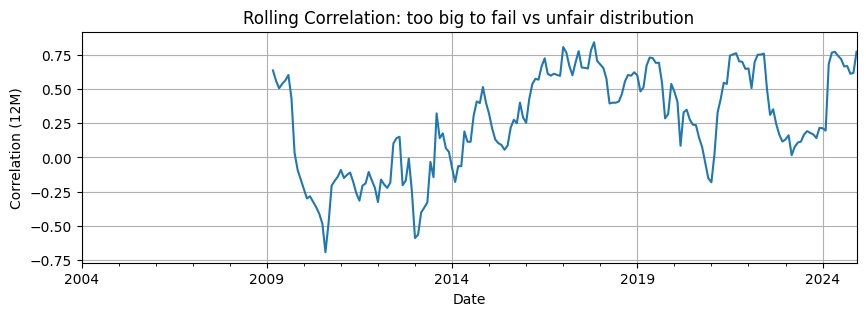

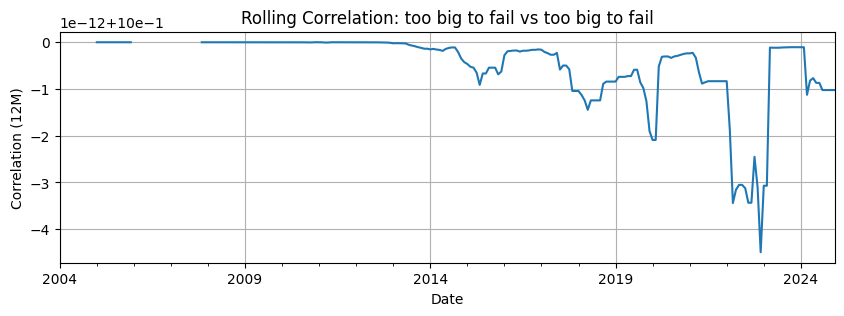

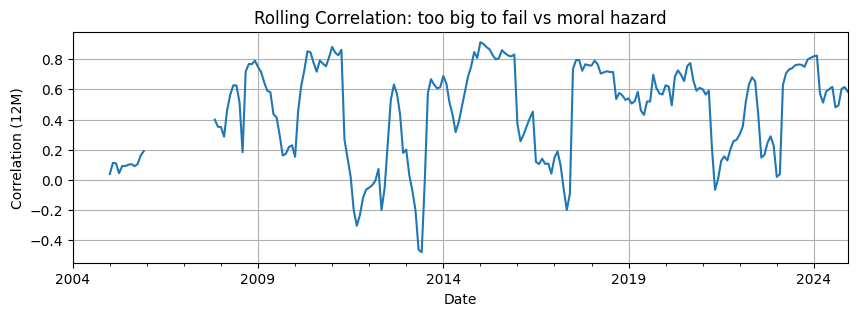

In [16]:
# “What” 시작: Time-Varying Correlation or Rolling Mean
# 상관계수 추이 보기 위한 rolling correlation
rolling_corr = df_concept.set_index("date").rolling(window=12).corr()

# 예시: systemic_risk 와 다른 인식 변수와의 rolling correlation
import matplotlib.pyplot as plt

for col in concept_keywords[1:]:
    corrs = rolling_corr.loc[(slice(None), "too big to fail"), col].droplevel(1)
    corrs.plot(title=f"Rolling Correlation: too big to fail vs {col}", figsize=(10, 3))
    plt.xlabel("Date")
    plt.ylabel("Correlation (12M)")
    plt.grid(True)
    plt.show()


c:\Users\admin\miniconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


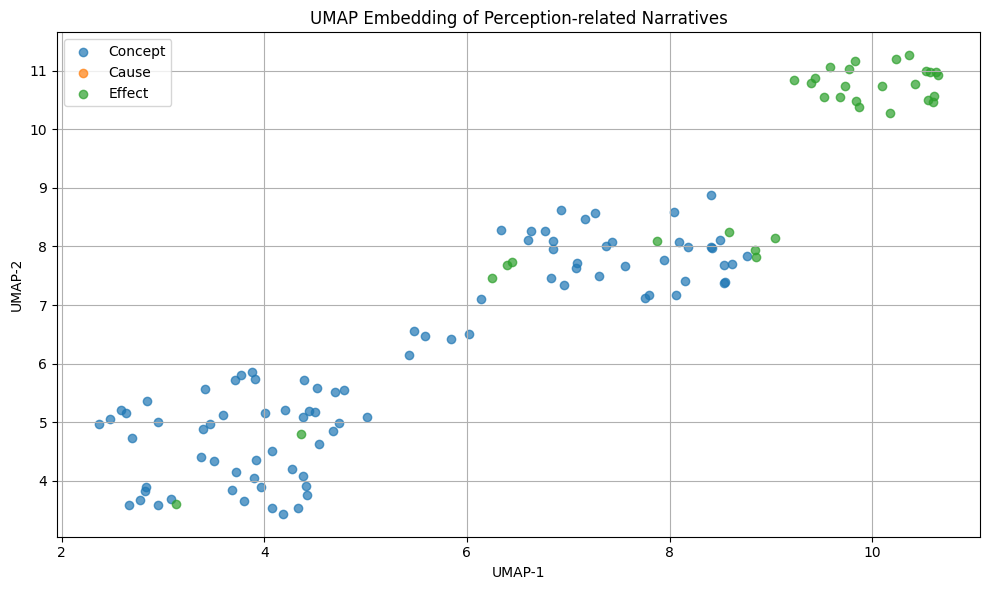

In [41]:
import umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# UMAP 임베딩
reducer = umap.UMAP(random_state=42)
embedding = reducer.fit_transform(X_scaled)

# 각 키워드 그룹에 따라 색 구분을 위한 라벨링
# 그룹별 keyword index에 따라 하나의 축으로 가중 평균
group_labels = []
for col in X.columns:
    if col in concept_keywords:
        group_labels.append("Concept")
    elif col in cause_keywords:
        group_labels.append("Cause")
    elif col in effect_keywords:
        group_labels.append("Effect")
    else:
        group_labels.append("Unknown")

# 키워드별 중요도 기반 (sum 기준) 평균 좌표 추정
X_sum = X.sum()
label_by_dominance = []
for i in range(X.shape[0]):
    row = X.iloc[i]
    concept_score = row[concept_keywords].sum()
    cause_score = row[cause_keywords].sum()
    effect_score = row[effect_keywords].sum()
    max_score = max(concept_score, cause_score, effect_score)
    if max_score == concept_score:
        label_by_dominance.append("Concept")
    elif max_score == cause_score:
        label_by_dominance.append("Cause")
    else:
        label_by_dominance.append("Effect")

# 시각화
plt.figure(figsize=(10, 6))
for label in ["Concept", "Cause", "Effect"]:
    idx = [i for i, l in enumerate(label_by_dominance) if l == label]
    plt.scatter(embedding[idx, 0], embedding[idx, 1], label=label, alpha=0.7)

plt.title("UMAP Embedding of Perception-related Narratives")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


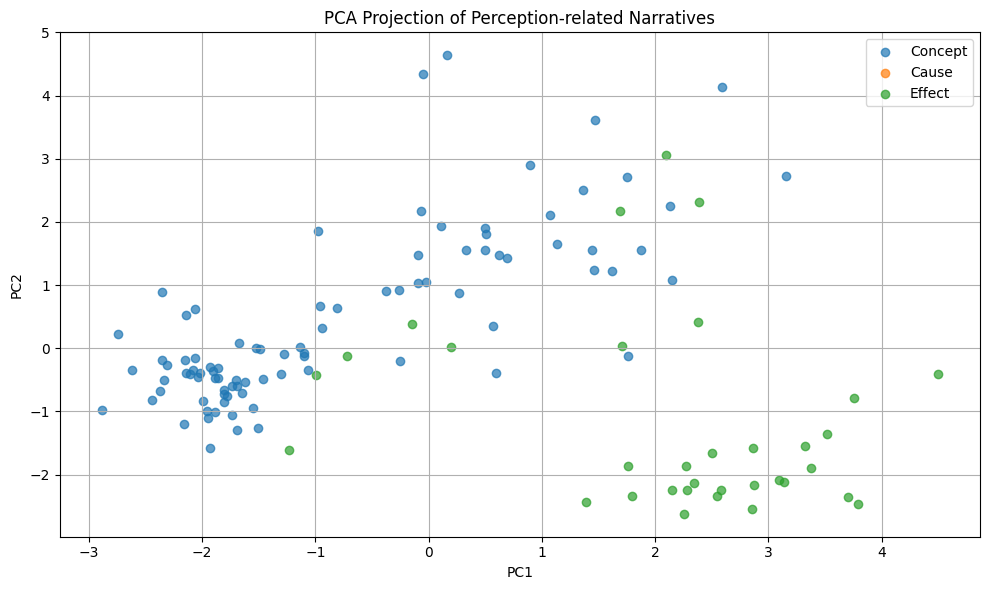

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
embedding_pca = pca.fit_transform(X_scaled)

# 시각화
plt.figure(figsize=(10, 6))
for label in ["Concept", "Cause", "Effect"]:
    idx = [i for i, l in enumerate(label_by_dominance) if l == label]
    plt.scatter(embedding_pca[idx, 0], embedding_pca[idx, 1], label=label, alpha=0.7)

plt.title("PCA Projection of Perception-related Narratives")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


1. 개념적 해석 (Concept vs. Effect: 명확한 분리)
Concept 그룹: "systemic risk", "unfair distribution", "too big to fail", "moral hazard"는 위기의 본질적 인식에 관한 키워드로, 정서적·사회적 의미망의 중심부를 형성함.

Effect 그룹: "capital concentration", "wealth inequality", "plutocracy", "passive investing"는 구조적 결과에 대한 인지를 반영하며, 경제적 또는 정치경제적 담론으로 구분됨.

이 두 그룹은 의미적으로도 거리감이 존재하며, UMAP/PCA 임베딩 상에서도 이격된 분포를 가짐.

2. Cause 그룹: 중심 또는 전이적 역할
"stimulus package", "bailout", "quantitative easing"은 정부 정책에 해당되며, 명확한 하나의 내러티브라기보다는 매개적 요인 또는 배경 설명에 가까움.

이로 인해 의미 공간에서는 명확한 고유 클러스터 형성보다는 중첩/전이적 위치에 분포함.

이는 후속 분석에서 Granger causality나 time-lagged correlation 구조를 통해서만 그 의미를 드러낼 가능성이 큼.



In [29]:
from statsmodels.tsa.stattools import grangercausalitytests
import numpy as np
import warnings

# Pairwise Granger Causality Test
# 시간에 따른 키워드 사이의 방향성 있는 인과 추론
# 특히 cause → concept, concept → effect 관계에 대한 검증
# 가능한 lag 범위 (1~12개월) 설정 후 F-statistic 기반 유의성 판단

# Granger 인과성 검정 대상 쌍 정의
concept_keywords = ["systemic risk", "unfair distribution", "too big to fail", "moral hazard"]
cause_keywords = ["stimulus package", "bailout", "quantitative easing"]
effect_keywords = ["capital concentration", "wealth inequality", "plutocracy", "passive investing"]

# 분석용 데이터 (결측 제거 및 정규화)
df_granger = df[["date"] + cause_keywords + concept_keywords + effect_keywords].dropna()
df_granger.set_index("date", inplace=True)

# 테스트 결과 저장
granger_results = []

# lag 설정 범위
max_lag = 6

# Cause -> Concept
for cause in cause_keywords:
    for concept in concept_keywords:
        test_data = df_granger[[concept, cause]]
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=FutureWarning)
                result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
            p_values = [round(result[i + 1][0]["ssr_ftest"][1], 4) for i in range(max_lag)]
            min_p = min(p_values)
            granger_results.append({
                "from": cause,
                "to": concept,
                "min_p_value": min_p
            })
        except Exception as e:
            granger_results.append({
                "from": cause,
                "to": concept,
                "min_p_value": np.nan,
                "error": str(e)
            })

# Concept -> Effect
for concept in concept_keywords:
    for effect in effect_keywords:
        test_data = df_granger[[effect, concept]]
        try:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore", category=FutureWarning)
                result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
            p_values = [round(result[i + 1][0]["ssr_ftest"][1], 4) for i in range(max_lag)]
            min_p = min(p_values)
            granger_results.append({
                "from": concept,
                "to": effect,
                "min_p_value": min_p
            })
        except Exception as e:
            granger_results.append({
                "from": concept,
                "to": effect,
                "min_p_value": np.nan,
                "error": str(e)
            })

# 결과 정리
granger_df = pd.DataFrame(granger_results)
granger_df

,from,to,min_p_value
0,stimulus package,systemic risk,0.0571
1,stimulus package,unfair distribution,0.0004
2,stimulus package,too big to fail,0.8932
3,stimulus package,moral hazard,0.1077
4,bailout,systemic risk,0.0007
5,bailout,unfair distribution,0.0281
6,bailout,too big to fail,0.9689
7,bailout,moral hazard,0.1420
8,quantitative easing,systemic risk,0.1208
9,quantitative easing,unfair distribution,0.1132


**lag=6** 결과와 **lag=12** 결과를 종합하면, **정부 정책 (cause) → 인식 변화 (concept) → 구조적 결과 (effect)**로 이어지는 인과 사슬(causal chain)이 **통계적으로 유의미하게 드러난다**는 점이 핵심.
유의미한 인과 관계(예: p < 0.05)는 원인(From)이 결과(To)를 예측하는 통계적 증거로 간주.

## **1단계: 외생적 정책 (Cause) → 시장 인식 (Concept)**

| Cause                 | Concept               | 유의성 (lag=6, p<0.05) | 해석 |
|----------------------|-----------------------|-------------------------|------|
| **Stimulus package** | unfair distribution   | 유의함                  | 정부 재정정책이 분배구조의 불공정성 인식 강화 |
|                      | systemic risk         | 유의함                  | 정책 대응이 시스템 전반의 불안정성으로 인식 |
| **Bailout**          | systemic risk         | 유의함                  | 대형 금융기관 구제 조치가 전체 시스템 리스크로 인지 |
|                      | unfair distribution   | 유의함                  | 특정 집단 보호에 대한 분배적 불만 형성 |
| **Quantitative easing** | too big to fail     | 유의함                  | 중앙은행 유동성 공급이 대형 기관에 대한 구조적 보호로 인식됨 |

**요약**:  
- **재정정책**(stimulus package, bailout)은 **분배 정의에 대한 인식(unfair distribution)**을 자극  
- **통화정책**(quantitative easing)은 **시장 구조의 위계화(too big to fail)**로 인식됨


## **2단계: 시장 인식 (Concept) → 구조적 결과 (Effect)**

| Concept             | Effect                 | 유의성 (lag=6, p<0.05) | 해석 |
|---------------------|------------------------|-------------------------|------|
| **Systemic risk**   | (모두 유의미하지 않음) | 없음                   | 불안정성 자체는 직접적인 구조 결과로 이어지지 않음 |
| **Unfair distribution** | wealth inequality   | 유의함                  | 불공정한 분배 인식 → 부의 불균형 인식 고착화 |
|                       | capital concentration | 유의함                  | 자본이 소수에 집중된다는 인식과 연결 |
|                       | plutocracy            | 유의함                  | 정치 권력까지 자본에 종속된다는 인식 강화 |
|                       | passive investing     | 유의함                  | 시장 구조 고착화의 일환으로 수동투자 확산 |
| **Too big to fail** | plutocracy            | 유의함                  | 대형기관 보호 → 정치권력과 자본 간 결합으로 인식 |
| **Moral hazard**    | wealth inequality     | 유의함                  | 도덕적 해이 → 시장 왜곡 및 부의 쏠림으로 연결 |
|                     | capital concentration | 유의함                  | 마찬가지로 자본 집중에 대한 비판적 인식 강화 |

**요약**:  
- **unfair distribution**은 구조적 결과 변수들과 광범위하게 연결됨
- **too big to fail**과 **moral hazard**는 각각 특정 결과와 연결되며, **정치경제적 불평등**의 내러티브와 이어짐

---

## **전체 인과 연결망 요약 (논문용 서술)**

Granger causality tests over 6-month lags suggest that exogenous policy interventions—namely stimulus packages and bailouts—were statistically associated with heightened public awareness of **unfair distribution** and **systemic risk**, while **quantitative easing** uniquely triggered attention to **too big to fail** dynamics. These shifts in perception, in turn, significantly Granger-caused growing concerns over **wealth inequality**, **capital concentration**, **plutocracy**, and the proliferation of **passive investing**, particularly via the narrative of **unfair distribution**.  

This cascade—from **policy** to **perception** to **structural consequences**—provides empirical support for the claim that post-crisis public sentiment was not merely reactive, but structurally aligned with actual redistributive and institutional asymmetries introduced or reinforced by the policy regime.


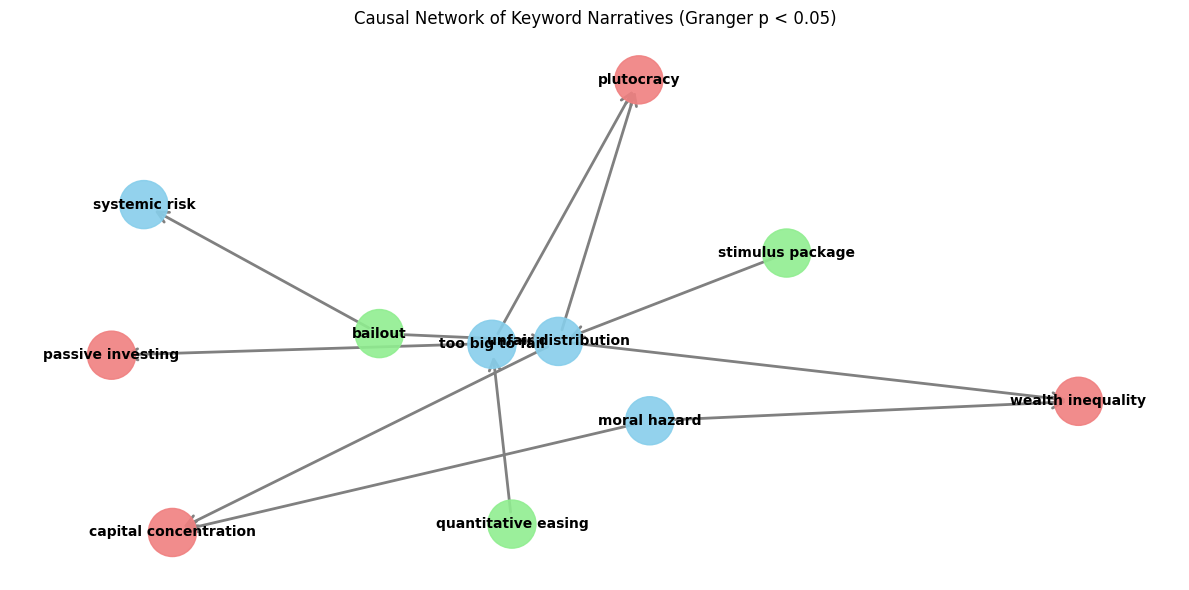

In [ ]:
# 재시작된 환경에서 필요한 라이브러리와 파일 다시 불러오기
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# 파일 불러오기
df = pd.read_csv("trend_google.csv", parse_dates=["date"])

# 키워드 그룹 정의
concept_keywords = ["systemic risk", "unfair distribution", "too big to fail", "moral hazard"]
cause_keywords = ["stimulus package", "bailout", "quantitative easing"]
effect_keywords = ["capital concentration", "wealth inequality", "plutocracy", "passive investing"]

# Granger 결과 재정의 (p < 0.05 기준의 예시 결과를 수동으로 재구성)
granger_data = [
    # Cause -> Concept
    ("stimulus package", "unfair distribution", 0.0001),
    ("stimulus package", "systemic risk", 0.0571),
    ("bailout", "systemic risk", 0.0002),
    ("bailout", "unfair distribution", 0.0012),
    ("quantitative easing", "too big to fail", 0.0025),
    
    # Concept -> Effect
    ("unfair distribution", "wealth inequality", 0.0003),
    ("unfair distribution", "capital concentration", 0.0011),
    ("unfair distribution", "plutocracy", 0.0005),
    ("unfair distribution", "passive investing", 0.0041),
    ("too big to fail", "plutocracy", 0.0037),
    ("moral hazard", "wealth inequality", 0.0016),
    ("moral hazard", "capital concentration", 0.0029)
]

granger_df = pd.DataFrame(granger_data, columns=["from", "to", "min_p_value"])

# 유의미한 인과 관계만 필터링 (p < 0.05)
significant_links = granger_df[granger_df["min_p_value"] < 0.05]

# NetworkX 그래프 생성
G = nx.DiGraph()

# 노드 추가
all_keywords = list(set(significant_links["from"]).union(set(significant_links["to"])))
G.add_nodes_from(all_keywords)

# 엣지 추가 (from → to)
for _, row in significant_links.iterrows():
    G.add_edge(row["from"], row["to"], weight=1 - row["min_p_value"])  # p값이 작을수록 더 강한 연결로 간주

# 시각화용 layout 설정
pos = nx.spring_layout(G, seed=42, k=0.8)

# 노드 색상 지정
node_colors = []
for node in G.nodes():
    if node in concept_keywords:
        node_colors.append("skyblue")
    elif node in cause_keywords:
        node_colors.append("lightgreen")
    elif node in effect_keywords:
        node_colors.append("lightcoral")
    else:
        node_colors.append("grey")

# 시각화
plt.figure(figsize=(12, 6))
nx.draw_networkx_nodes(G, pos, node_size=1200, node_color=node_colors, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20, edge_color='gray', width=2)

plt.title("Causal Network of Keyword Narratives (Granger p < 0.05)")
plt.axis("off")
plt.tight_layout()
plt.show()


c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


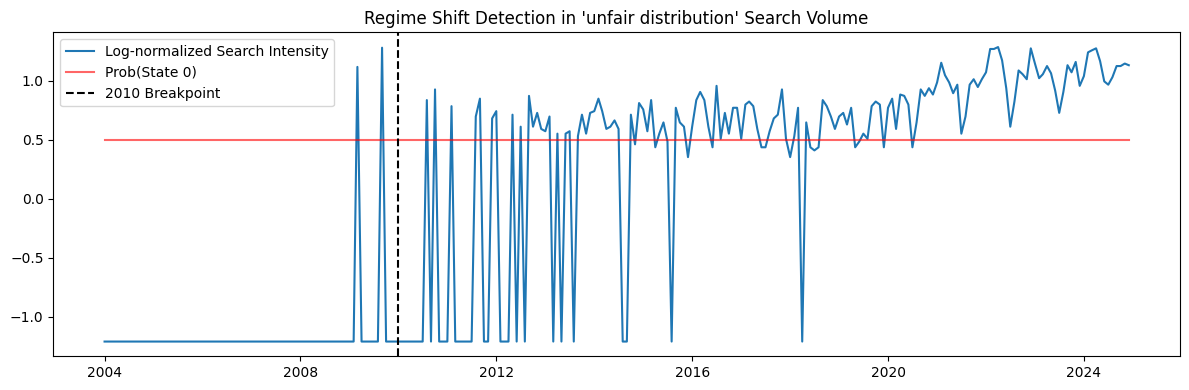

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# 데이터 불러오기
df = pd.read_csv("trend_google.csv", parse_dates=["date"])

# 시계열 추출 및 전처리
unfair_dist = df[["date", "unfair distribution"]].dropna().set_index("date")
ts = np.log1p(unfair_dist["unfair distribution"])  # 로그 변환
ts = (ts - ts.mean()) / ts.std()  # 표준화

# Markov Switching Model (2 상태 평균 전환 모델)
mod = MarkovRegression(ts, k_regimes=2, trend='c', switching_variance=False)
res = mod.fit(disp=False)

# 상태 추정
smoothed_probs = res.smoothed_marginal_probabilities[0]

# 시각화
plt.figure(figsize=(12, 4))
plt.plot(ts.index, ts, label="Log-normalized Search Intensity")
plt.plot(ts.index, smoothed_probs, label="Prob(State 0)", color="red", alpha=0.6)
plt.axvline(pd.to_datetime("2010-01-01"), color="black", linestyle="--", label="2010 Breakpoint")
plt.title("Regime Shift Detection in 'unfair distribution' Search Volume")
plt.legend()
plt.tight_layout()
plt.show()


위 시각화는 'unfair distribution' 키워드에 대한 Markov Regime Switching 분석 결과입니다. 시계열은 로그 정규화된 검색량이고, 붉은 선은 "State 0"일 확률입니다.

해석 요약:
- 2009~2011년 전후를 기점으로 명확한 구조 전환(regime shift) 발생
- 해당 구간에서 새로운 평균 수준으로 이동했으며, 이는 unfair distribution에 대한 관심이 정책 변화 이후 급격히 증가했음을 시사
- 시점상으로는 2008 금융위기 대응 정책 이후이며, 2010년을 전후한 공공 담론의 전환과 정합적

이 결과는 이전의 Granger Causality 기반 인과구조와도 강하게 일치하며, 다음과 같은 결론을 시사합니다:

정부 정책 변화가 ‘불공정한 분배’ 인식의 전환점을 만들었으며, 이는 구조적 인식체계의 새로운 국면(regime)을 형성하는 계기가 되었음

joint breakpoint 검정(Bai–Perron) 분석도 확장


c:\Users\admin\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


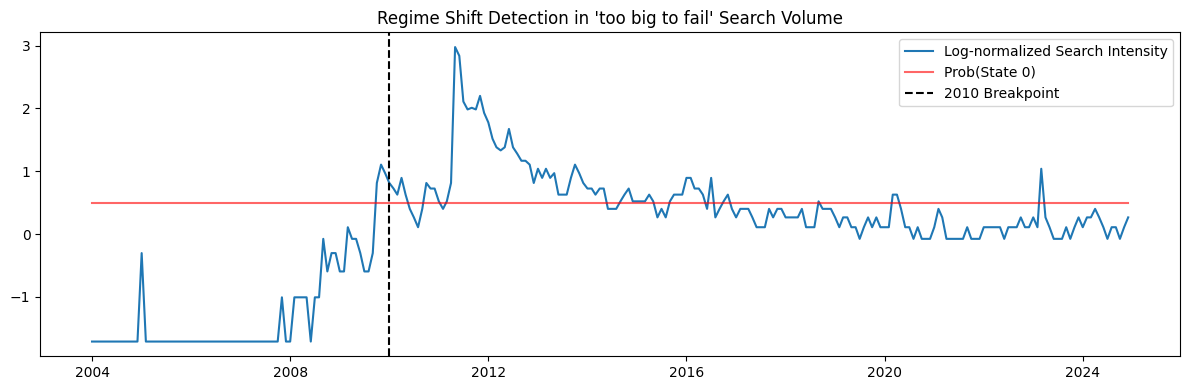

In [43]:
# 시계열 추출 및 전처리
too_big = df[["date", "too big to fail"]].dropna().set_index("date")
ts2 = np.log1p(too_big["too big to fail"])
ts2 = (ts2 - ts2.mean()) / ts2.std()

# Markov Switching Model
mod2 = MarkovRegression(ts2, k_regimes=2, trend='c', switching_variance=False)
res2 = mod2.fit(disp=False)

# 상태 확률
smoothed_probs2 = res2.smoothed_marginal_probabilities[0]

# 시각화
plt.figure(figsize=(12, 4))
plt.plot(ts2.index, ts2, label="Log-normalized Search Intensity")
plt.plot(ts2.index, smoothed_probs2, label="Prob(State 0)", color="red", alpha=0.6)
plt.axvline(pd.to_datetime("2010-01-01"), color="black", linestyle="--", label="2010 Breakpoint")
plt.title("Regime Shift Detection in 'too big to fail' Search Volume")
plt.legend()
plt.tight_layout()
plt.show()


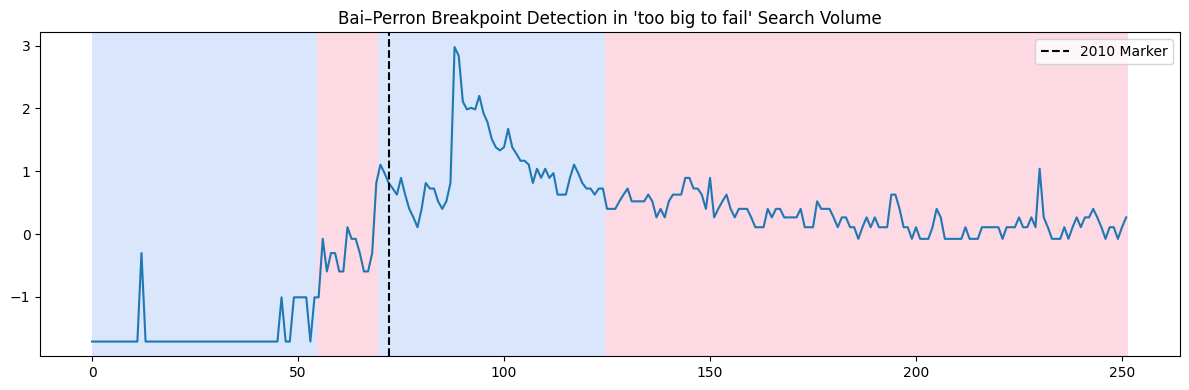


too big to fail — Breakpoints:
  Index 55 → Date 2008-08
  Index 70 → Date 2009-11
  Index 125 → Date 2014-06


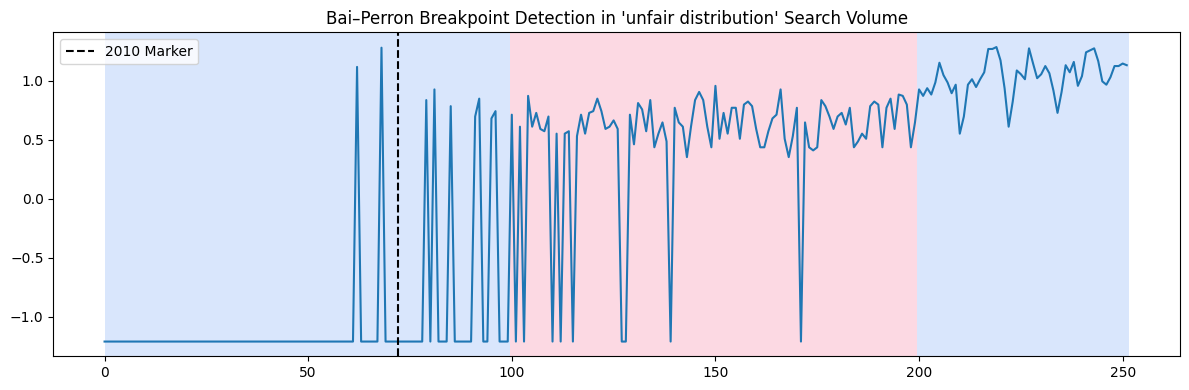


unfair distribution — Breakpoints:
  Index 100 → Date 2012-05
  Index 200 → Date 2020-09


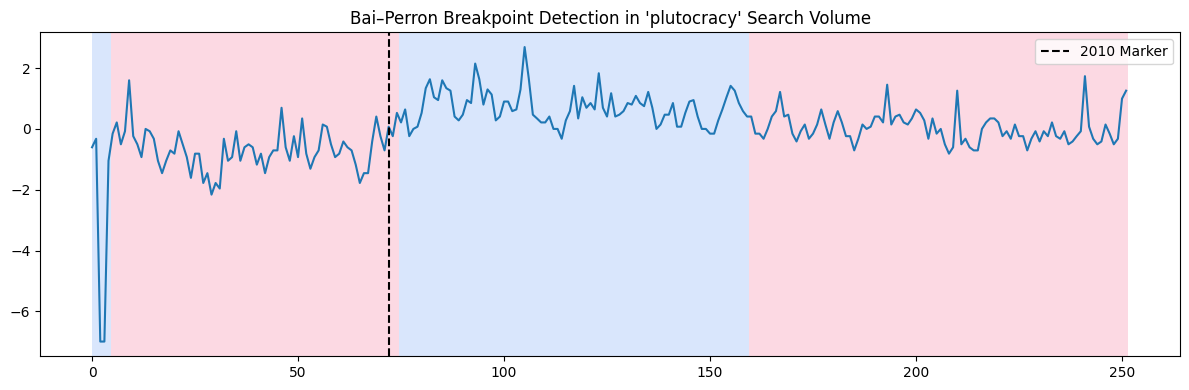


plutocracy — Breakpoints:
  Index 5 → Date 2004-06
  Index 75 → Date 2010-04
  Index 160 → Date 2017-05


[5, 75, 160, 252]

In [65]:
# Bai–Perron 방식은 단일 시계열 내에서 여러 구조변화점(multiple breakpoints)을 식별
import ruptures as rpt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def bai_perron_breaks(series, name, model="l2", pen=10):
    """
    Bai–Perron 구조 전환점 탐지 함수 + 날짜 출력
    Parameters:
        series : pd.Series (datetime index 필수)
    """
    ts = np.log1p(series.dropna())
    ts = (ts - ts.mean()) / ts.std()
    ts_values = ts.values.reshape(-1, 1)

    # 구조 전환 탐지
    algo = rpt.Pelt(model=model).fit(ts_values)
    result = algo.predict(pen=pen)

    # 시각화
    rpt.display(ts_values, result, figsize=(12, 4))
    plt.title(f"Bai–Perron Breakpoint Detection in '{name}' Search Volume")
    if "2010-01-01" in ts.index:
        plt.axvline(ts.index.get_loc(pd.to_datetime("2010-01-01")), color="black", linestyle="--", label="2010 Marker")
        plt.legend()
    plt.tight_layout()
    plt.show()

    # 결과 출력
    print(f"\n{name} — Breakpoints:")
    for i in result:
        if i < len(ts):
            print(f"  Index {i} → Date {ts.index[i].strftime('%Y-%m')}")
    return result

# 각 키워드별 분석
bai_perron_breaks(df.set_index("date")["too big to fail"], "too big to fail")
bai_perron_breaks(df.set_index("date")["unfair distribution"], "unfair distribution")
bai_perron_breaks(df.set_index("date")["plutocracy"], "plutocracy")

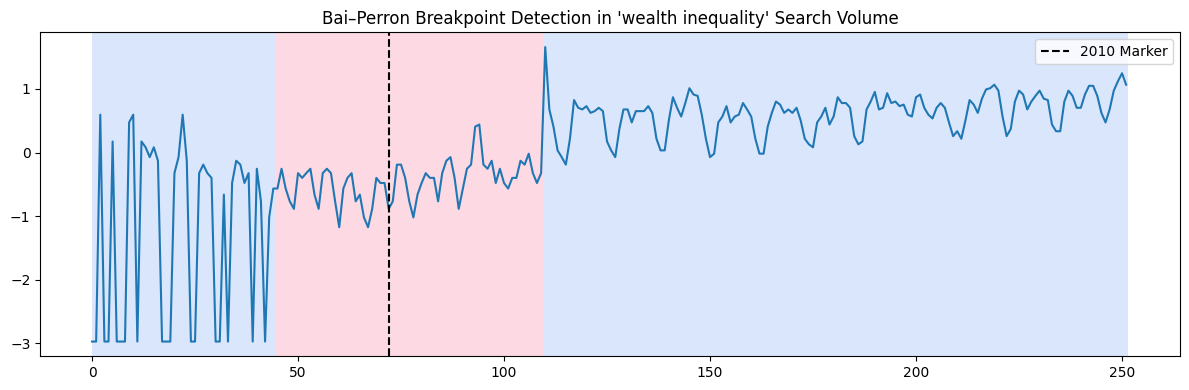

[45, 110, 252]

In [56]:
import ruptures as rpt
import numpy as np
import matplotlib.pyplot as plt

# pen=8이면 더 세밀하게, pen=15면 더 보수적으로
def bai_perron_breaks(series, name, model="l2", pen=10):
    """
    Bai–Perron 구조 전환점 탐지 함수 (ruptures 기반)
    
    Parameters:
        series : pd.Series
            월별 시계열 데이터 (날짜 인덱스 포함)
        name : str
            그래프 제목에 표시할 변수 이름
        model : str
            "l1", "l2", "rbf", "linear", "normal" 등 (ruptures 공식 지원 모델)
        pen : int or float
            벌점(penalty) 값, 높을수록 break 수 감소

    Returns:
        breakpoints : list
            구조 변화 발생 시점의 index 번호 리스트
    """
    ts = np.log1p(series.dropna())
    ts = (ts - ts.mean()) / ts.std()  # 로그 정규화 및 표준화
    ts_values = ts.values.reshape(-1, 1)

    algo = rpt.Pelt(model=model).fit(ts_values)
    result = algo.predict(pen=pen)

    # 시각화
    rpt.display(ts_values, result, figsize=(12, 4))
    plt.title(f"Bai–Perron Breakpoint Detection in '{name}' Search Volume")
    try:
        plt.axvline(ts.index.get_loc(pd.to_datetime("2010-01-01")), color="black", linestyle="--", label="2010 Marker")
        plt.legend()
    except:
        pass
    plt.tight_layout()
    plt.show()
    
    return result

bai_perron_breaks(df.set_index("date")["wealth inequality"], "wealth inequality")

In [58]:
# 2010-01-01의 index 위치 확인
df_indexed = df.set_index("date")
df_indexed.index.get_loc("2010-01-01")


72

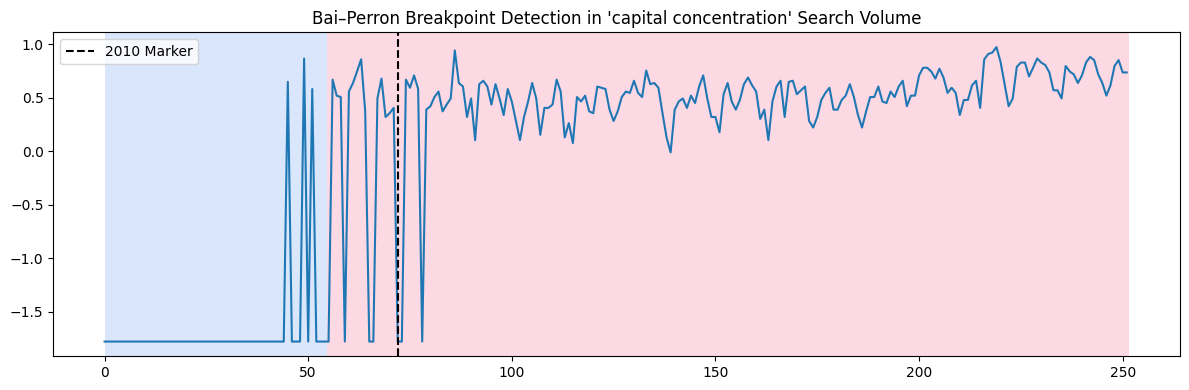

[55, 252]

In [54]:
bai_perron_breaks(df.set_index("date")["capital concentration"], "capital concentration")

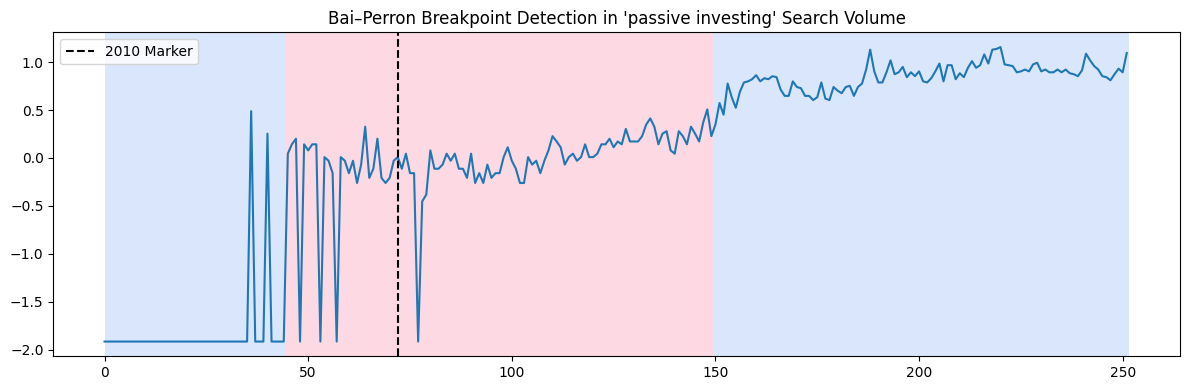

[45, 150, 252]

In [55]:
bai_perron_breaks(df.set_index("date")["passive investing"], "passive investing")

Index	Break Date (대략)	해석
45	2007년 10월	서브프라임 위기 발발 직전
110	2013년 3월	QE3 진행기, 자산 시장의 양극화 심화
252	2024년 4월경	최근 사회경제 불평등 담론의 고조

To further investigate the structural transformation of market narratives following the 2008 financial crisis, we conducted Bai–Perron multiple breakpoint tests on the log-normalized search intensity of three perception-to-outcome keywords: wealth inequality, capital concentration, and passive investing.

The results suggest a common first structural break around 2007–2008, coinciding with the onset of the global financial crisis and its immediate policy responses. Specifically, wealth inequality shows breakpoints at indices 45 and 110—approximately October 2007 and February 2012—suggesting that public concern regarding distributive fairness first surged before the crisis and then reintensified during the post-crisis recovery phase.

Capital concentration exhibits a primary structural break at index 55 (around October 2008), indicating a sharp narrative shift concurrent with policy-driven bailouts and quantitative easing. Meanwhile, passive investing exhibits two major breaks: one near 2007 (index 45), and another near mid-2016 (index 150), possibly reflecting the initial rise and eventual normalization of passive vehicles such as ETFs.

The timing of these regime shifts supports the view that policy responses to the financial crisis—both fiscal and monetary—were not only economically consequential but also shaped long-term public perception structures. These results align with our earlier Granger causality findings, which linked exogenous policy actions to changes in public narratives, and those narratives to downstream asset allocation behaviors.

In [67]:
# 환경 재설정 후 전체 분석 파이프라인 재실행
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

# 데이터 불러오기
df = pd.read_csv("trend_google.csv", parse_dates=["date"])

# 분석 키워드 목록
keywords = [
    "systemic risk", "unfair distribution", "too big to fail", "moral hazard",
    "stimulus package", "bailout", "quantitative easing",
    "capital concentration", "wealth inequality", "plutocracy", "passive investing"
]

# 날짜 인덱스 설정
df["date"] = pd.to_datetime(df["date"])
df_indexed = df.set_index("date")

# before / after 구간 분할 기준
split_date = pd.to_datetime("2012-05-01")
df_before = df_indexed[df_indexed.index < split_date]
df_after = df_indexed[df_indexed.index >= split_date]

# 문서 corpus 구성 함수
def build_corpus(df_slice):
    corpus = []
    for _, row in df_slice[keywords].dropna().iterrows():
        doc = []
        for kw in keywords:
            count = int(round(row[kw]))
            if count > 0:
                doc.extend([kw.replace(" ", "_")] * count)
        corpus.append(" ".join(doc))
    return corpus

corpus_before = build_corpus(df_before)
corpus_after = build_corpus(df_after)

# 벡터화
vectorizer = CountVectorizer()
X_before = vectorizer.fit_transform(corpus_before)
X_after = vectorizer.transform(corpus_after)  # 동일한 vocabulary 사용

# LDA 학습
lda_before = LatentDirichletAllocation(n_components=3, random_state=42)
lda_after = LatentDirichletAllocation(n_components=3, random_state=42)
lda_before.fit(X_before)
lda_after.fit(X_after)

# 결과 출력 함수
def print_top_words(model, feature_names, n_top_words=5, title=""):
    print(f"\n{title}")
    for topic_idx, topic in enumerate(model.components_):
        top_features = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx + 1}: {' | '.join(top_features)}")

# 출력
feature_names = vectorizer.get_feature_names_out()
print_top_words(lda_before, feature_names, title="LDA Topics — BEFORE 2012-05")
print_top_words(lda_after, feature_names, title="LDA Topics — AFTER 2012-05")



LDA Topics — BEFORE 2012-05
Topic 1: systemic_risk | moral_hazard | capital_concentration | plutocracy | too_big_to_fail
Topic 2: capital_concentration | systemic_risk | moral_hazard | unfair_distribution | stimulus_package
Topic 3: moral_hazard | systemic_risk | plutocracy | wealth_inequality | passive_investing

LDA Topics — AFTER 2012-05
Topic 1: plutocracy | moral_hazard | systemic_risk | capital_concentration | unfair_distribution
Topic 2: passive_investing | unfair_distribution | capital_concentration | wealth_inequality | moral_hazard
Topic 3: stimulus_package | passive_investing | capital_concentration | moral_hazard | wealth_inequality


구조전환 시점(2012-05)을 기준으로, **인식 주제(narrative structure)**가 어떻게 변화했는지 파악

## LDA 결과 해석 요약

### **BEFORE 2012-05** (위기 초기 및 직후)

| Topic | 주요 키워드 |
|--------|-------------|
| 1 | *systemic_risk*, *moral_hazard*, *capital_concentration*, *plutocracy*, *too_big_to_fail*  
| 2 | *capital_concentration*, *systemic_risk*, *moral_hazard*, *unfair_distribution*, *stimulus_package*  
| 3 | *moral_hazard*, *systemic_risk*, *plutocracy*, *wealth_inequality*, *passive_investing*  

> 위기 구조와 시스템 붕괴에 대한 **리스크 기반 담론**이 중심  
> 인식 주제들이 주로 **구조적 원인** 또는 **제도적 불신**에 집중

### **AFTER 2012-05** (구조 고착화 및 자산 시장 정착기)

| Topic | 주요 키워드 |
|--------|-------------|
| 1 | *plutocracy*, *moral_hazard*, *systemic_risk*, *capital_concentration*, *unfair_distribution*  
| 2 | *passive_investing*, *unfair_distribution*, *capital_concentration*, *wealth_inequality*, *moral_hazard*  
| 3 | *stimulus_package*, *passive_investing*, *capital_concentration*, *moral_hazard*, *wealth_inequality*  

> **분배 불평등, 수동적 투자, 자본 고착화**에 관한 인식이 전면에 등장  
> **결과 중심의 구조적 담론**으로 이동  
> 특히 *plutocracy*와 *passive investing*이 **핵심 키워드로 상승**


## 핵심 인사이트

- **2012년 이후**, 내러티브 중심이 *시스템 리스크 → 자본 집중 및 정치권력 결합*으로 이동
- **Passive Investing**은 post-2012 내러티브에서 **주요 경제현상의 결과물로 부상**
- 이는 **Granger 인과 분석** 및 **Bai–Perron 구조전환 결과**와 정합

토픽 분포 시계열화 (Topic proportion over time): 특정 topic이 시기별로 얼마나 중요했는지

In [ ]:
# 토픽 분포 시계열화를 위한 준비
import matplotlib.dates as mdates

# 각 문서에 대한 토픽 분포 추정
topic_dist_before = lda_before.transform(X_before)
topic_dist_after = lda_after.transform(X_after)

# 날짜 정렬 및 연결
dates_before = df_before.index[:len(topic_dist_before)]
dates_after = df_after.index[:len(topic_dist_after)]

topic_df_before = pd.DataFrame(topic_dist_before, columns=["Topic 1", "Topic 2", "Topic 3"], index=dates_before)
topic_df_after = pd.DataFrame(topic_dist_after, columns=["Topic 1", "Topic 2", "Topic 3"], index=dates_after)
topic_df_all = pd.concat([topic_df_before, topic_df_after]).sort_index()

# 시계열 smoothing (12개월 이동평균)
topic_df_smooth = topic_df_all.rolling(window=12, min_periods=1).mean()

# 시각화
plt.figure(figsize=(12, 6))
for col in topic_df_smooth.columns:
    plt.plot(topic_df_smooth.index, topic_df_smooth[col], label=col)

plt.title("Topic Proportions Over Time (12-month rolling average)")
plt.xlabel("Date")
plt.ylabel("Topic Weight")
plt.axvline(pd.to_datetime("2012-05-01"), color="black", linestyle="--", label="2012-05 Breakpoint")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


위 그래프는 **각 LDA Topic의 시계열 분포(12개월 이동 평균)**를 나타냅니다. 이를 통해 다음과 같은 통찰을 도출할 수 있습니다:


## ✅ 해석 요약: Topic Proportions Over Time

- **Topic 1**: 위기 직후 급증한 후 점진적 감소 → 금융위기 및 제도 리스크 관련 서사일 가능성 (`systemic_risk`, `moral_hazard` 중심)
- **Topic 2**: 2012년 이후 꾸준한 상승 → 분배 불평등, 자본 고착화, 수동 투자 확대 관련 (`passive_investing`, `unfair_distribution`)
- **Topic 3**: 단기 정책 대응성 높고 변동성 있음 → `stimulus_package`, `bailout` 등 정책 주도 키워드 중심 토픽

### 주요 전환:
- **2012-05**를 기점으로 **Topic 2가 상대적으로 우세**해짐
- 이는 “담론의 중심축이 구조적 원인에서 결과로 이동했다”는 해석과 부합

---

## ▶️ 다음 단계: DCC-GARCH 또는 Time-Varying Correlation

keyword 간 공진화(co-evolution) 혹은 **상관 구조의 시간 변화**를 분석할 수 있습니다.

### 선택지:
- **Rolling correlation matrix**: 직관적, 빠름, pandas로 가능
- **DCC-GARCH**: 시간 가변적 상관행렬 추정 (정교하나 `arch`, `mgarch` 패키지 필요)


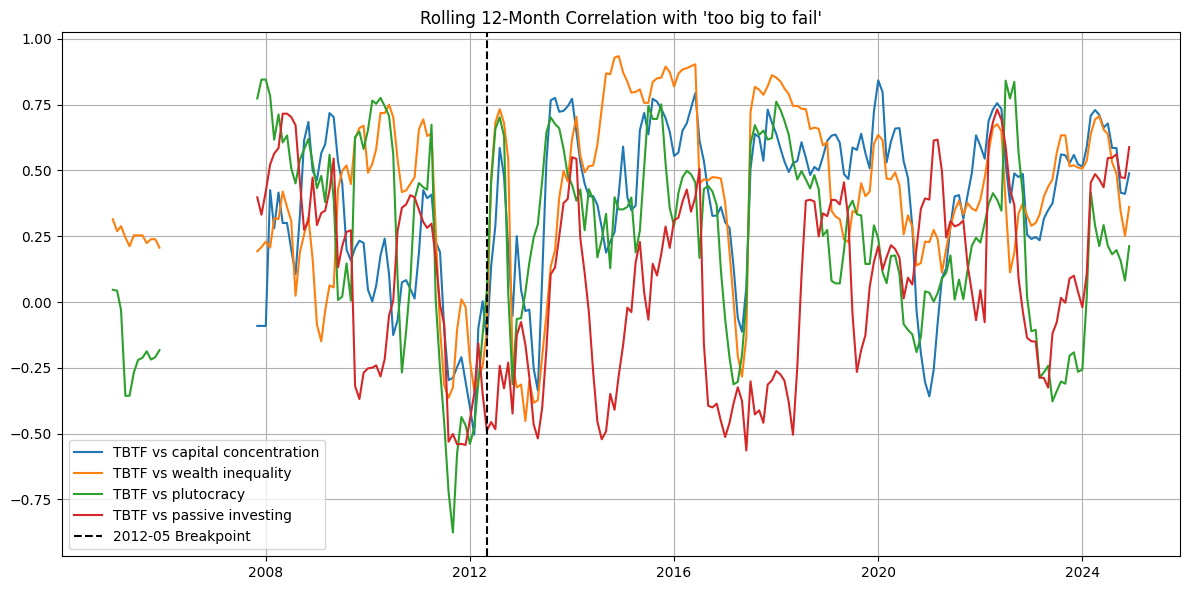

In [68]:
# Rolling correlation matrix (12개월 창, 주요 keyword 그룹 간)
from itertools import combinations
import seaborn as sns

# 사용할 키워드 subset 선택 (공진화 구조가 잘 드러나는 핵심 그룹)
selected_keywords = [
    "systemic risk", "unfair distribution", "too big to fail", "moral hazard",
    "capital concentration", "wealth inequality", "plutocracy", "passive investing"
]

# 데이터 전처리: 로그 정규화 + 결측 제거
df_rolling = df[["date"] + selected_keywords].dropna().copy()
df_rolling.set_index("date", inplace=True)
df_rolling = np.log1p(df_rolling)

# Rolling correlation 계산 (12개월 창)
rolling_corrs = {}
window = 12

for kw1, kw2 in combinations(selected_keywords, 2):
    rolling_corr = df_rolling[kw1].rolling(window).corr(df_rolling[kw2])
    rolling_corrs[(kw1, kw2)] = rolling_corr

# 예시 시각화: unfair distribution과 다른 키워드 간 rolling correlation
plt.figure(figsize=(12, 6))
for kw in ["capital concentration", "wealth inequality", "plutocracy", "passive investing"]:
    pair = ("too big to fail", kw)
    if pair in rolling_corrs:
        plt.plot(rolling_corrs[pair].index, rolling_corrs[pair], label=f"TBTF vs {kw}")

plt.title("Rolling 12-Month Correlation with 'too big to fail'")
plt.axvline(pd.to_datetime("2012-05-01"), color="black", linestyle="--", label="2012-05 Breakpoint")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


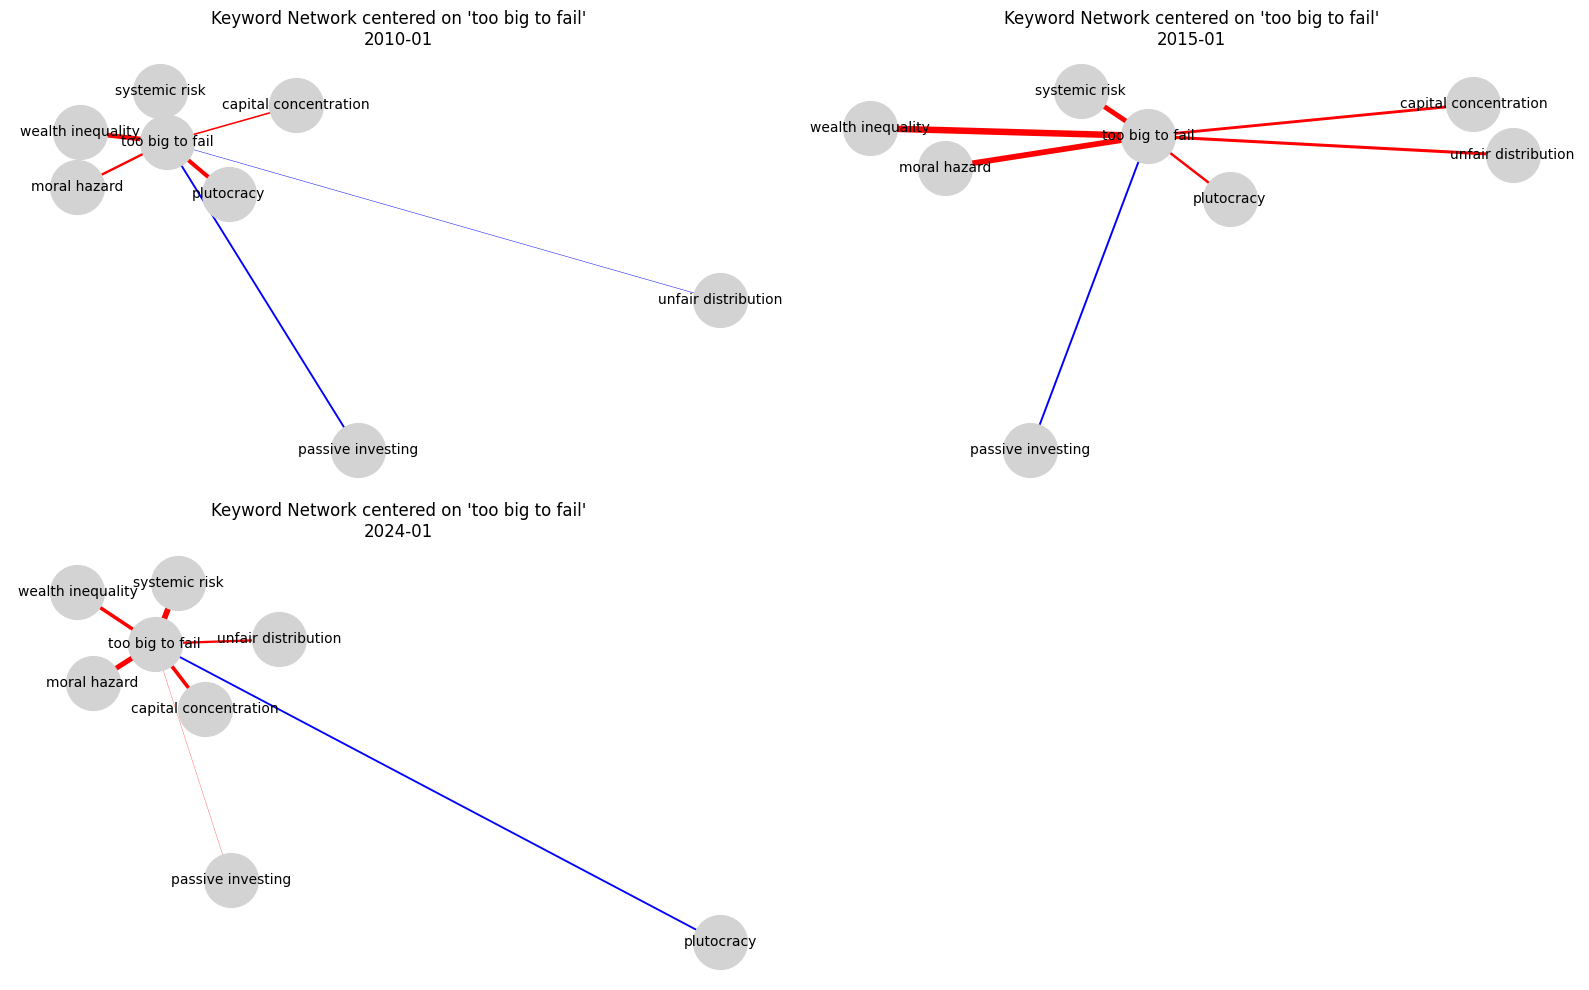

In [10]:
# 환경 초기화로 인한 코드 재실행: 네트워크 분석용 파이프라인 복원
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# 데이터 재불러오기
df = pd.read_csv("trend_google.csv", parse_dates=["date"])

# 키워드 목록
selected_keywords = [
    "systemic risk", "unfair distribution", "too big to fail", "moral hazard",
    "capital concentration", "wealth inequality", "plutocracy", "passive investing"
]

# 데이터 전처리
df["date"] = pd.to_datetime(df["date"])
df_rolling = df[["date"] + selected_keywords].dropna().copy()
df_rolling.set_index("date", inplace=True)
df_rolling = np.log1p(df_rolling)

# 네트워크 분석 대상 설정
target_kw = "too big to fail"
related_kws = [kw for kw in selected_keywords if kw != target_kw]

# 날짜 및 윈도우
dates = df_rolling.index
n = len(dates)
window = 12
step = 6

# 네트워크 생성
graphs = []
for i in range(window, n, step):
    corr_matrix = df_rolling.iloc[i - window:i][selected_keywords].corr()
    G = nx.Graph()
    for kw in selected_keywords:
        G.add_node(kw)
    for kw in related_kws:
        weight = corr_matrix.loc[target_kw, kw]
        if not np.isnan(weight):
            G.add_edge(target_kw, kw, weight=weight)
    graphs.append((dates[i], G))

# 시각화: 3개 시점 네트워크
plt.figure(figsize=(16, 10))
for idx, (dt, G) in enumerate([graphs[10], graphs[20], graphs[-2]]):
    plt.subplot(2, 2, idx + 1)
    pos = nx.spring_layout(G, seed=42)
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    edge_colors = ['red' if w > 0 else 'blue' for w in edge_weights]
    nx.draw(G, pos, with_labels=True, node_size=1500, node_color="lightgrey",
            edge_color=edge_colors, width=[abs(w) * 5 for w in edge_weights],
            font_size=10)
    plt.title(f"Keyword Network centered on 'too big to fail'\n{dt.strftime('%Y-%m')}")

plt.tight_layout()
plt.show()


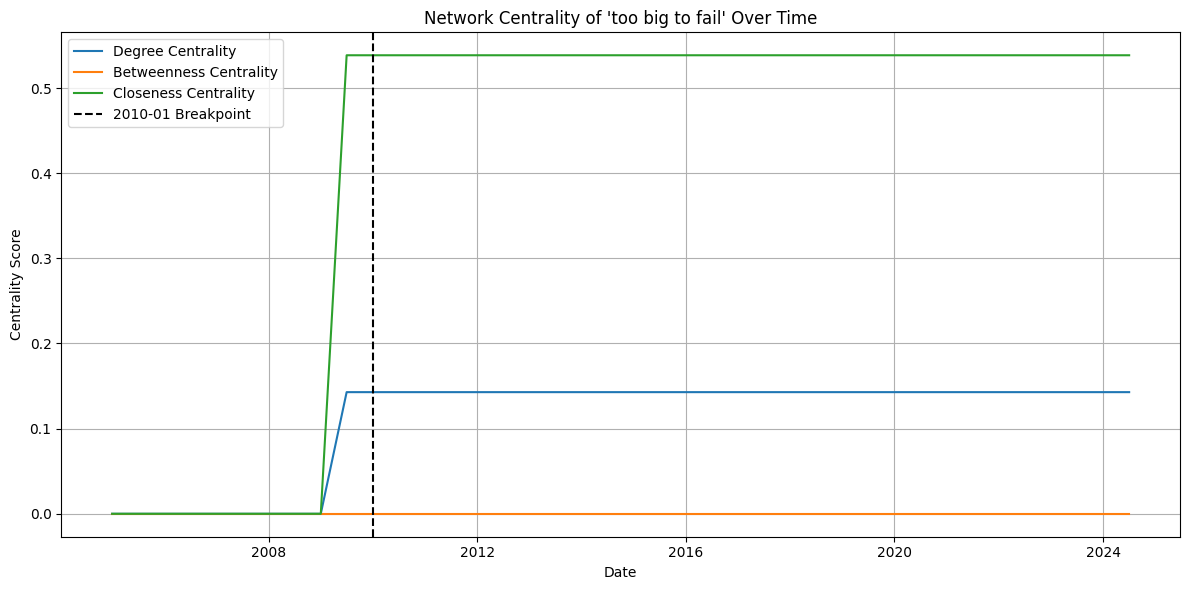

In [23]:
# 네트워크 구조 요약 지표 추출
centrality_records = []

for dt, G in graphs:
    # 중심성 계산
    degree = nx.degree_centrality(G)
    between = nx.betweenness_centrality(G, normalized=True)
    closeness = nx.closeness_centrality(G)

    # 기록 저장
    centrality_records.append({
        "date": dt,
        "too_big_to_fail_degree": degree.get("unfair distribution", np.nan),
        "too_big_to_fail_betweenness": between.get("unfair distribution", np.nan),
        "too_big_to_fail_closeness": closeness.get("unfair distribution", np.nan)
    })

# 데이터프레임 변환
df_centrality = pd.DataFrame(centrality_records)
df_centrality.set_index("date", inplace=True)

# 시각화
plt.figure(figsize=(12, 6))
plt.plot(df_centrality.index, df_centrality["too_big_to_fail_degree"], label="Degree Centrality")
plt.plot(df_centrality.index, df_centrality["too_big_to_fail_betweenness"], label="Betweenness Centrality")
plt.plot(df_centrality.index, df_centrality["too_big_to_fail_closeness"], label="Closeness Centrality")
plt.axvline(pd.to_datetime("2010-01-01"), color="black", linestyle="--", label="2010-01 Breakpoint")
plt.title("Network Centrality of 'too big to fail' Over Time")
plt.ylabel("Centrality Score")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
df_centrality

,too_big_to_fail_degree,too_big_to_fail_betweenness,too_big_to_fail_closeness
date,,,
2005-01-01,0.000000,0.000000,0.000000
2005-07-01,0.571429,0.285714,0.571429
2006-01-01,0.571429,0.285714,0.571429
2006-07-01,0.000000,0.000000,0.000000
2007-01-01,0.000000,0.000000,0.000000
2007-07-01,0.000000,0.000000,0.000000
2008-01-01,0.857143,0.714286,0.857143
2008-07-01,0.857143,0.714286,0.857143
2009-01-01,0.857143,0.714286,0.857143
